<a href="https://colab.research.google.com/github/akhilanandam/ML/blob/main/Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
from sklearn.impute import SimpleImputer

In [8]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [9]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [10]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [11]:
X_pima = pima_df[pima_cols[:-1]].copy()

In [12]:
y_pima = pima_df['Outcome']

In [13]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [14]:
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)

In [15]:
imputer = SimpleImputer(strategy='median')

In [16]:
X_imputed = imputer.fit_transform(X_pima)

In [17]:
scaler = StandardScaler()

In [18]:
X_pima_scaled = scaler.fit_transform(X_imputed)

In [19]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [20]:
print("Preprocessed Pima dataset shapes:")
print(f"  Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")

Preprocessed Pima dataset shapes:
  Training set features: (614, 8) | Test set features: (154, 8)


In [21]:
import tensorflow as tf

In [22]:
from tensorflow.keras.models import Sequential

In [23]:
from tensorflow.keras.layers import Dense

In [24]:
ann_pima = Sequential([
    Dense(16, activation='relu', input_shape=(8,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [25]:
print("Sequential ANN Architecture established:")
ann_pima.summary()

Sequential ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Neural network model compiled successfully.")

Neural network model compiled successfully.


In [27]:
history_pima = ann_pima.fit(
    X_train_p,
    y_train_p,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6721 - loss: 0.6663 - val_accuracy: 0.7073 - val_loss: 0.6135
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7352 - loss: 0.6138 - val_accuracy: 0.7480 - val_loss: 0.5708
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7413 - loss: 0.5731 - val_accuracy: 0.7561 - val_loss: 0.5415
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7434 - loss: 0.5416 - val_accuracy: 0.7642 - val_loss: 0.5185
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7556 - loss: 0.5166 - val_accuracy: 0.7642 - val_loss: 0.4992
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7658 - loss: 0.4984 - val_accuracy: 0.7642 - val_loss: 0.4901
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7699 - loss: 0.4848 - val_accuracy: 0.7724 - val_loss: 0.4790
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7719 - loss: 0.4743 - val_accuracy: 0.7886 - val_loss

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [29]:
import seaborn as sns

In [30]:
import matplotlib.pyplot as plt

In [31]:
y_pred_probs = ann_pima.predict(X_test_p)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [32]:
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

In [33]:
test_acc = accuracy_score(y_test_p, y_pred_classes)

ANN Holdout Test Accuracy: 75.97%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.82      0.81      0.81       100
    Diabetes       0.65      0.67      0.66        54

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



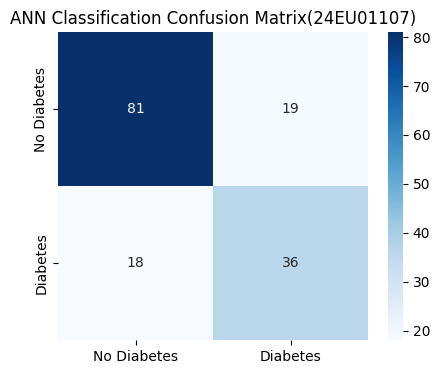

In [35]:
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))

# Plot confusion matrix
cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("ANN Classification Confusion Matrix(24EU01107)")
plt.show()

In [36]:
import warnings

In [37]:
warnings.filterwarnings("ignore")

In [38]:
import pandas as pd

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [42]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [43]:
sonar_columns = sonar_features + ['Class']

In [44]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [45]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [46]:
X_sonar = sonar_df[sonar_features]

In [47]:
y_sonar = sonar_df['Class_numeric']

In [48]:
scaler_sonar = StandardScaler()

In [49]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [50]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [51]:
print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [52]:
from tensorflow.keras.models import Sequential

In [53]:
from tensorflow.keras.layers import Dense, Dropout

In [54]:
ann_sonar = Sequential([
    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [55]:
print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()

Regularized Sonar ANN Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [57]:
history_sonar = ann_sonar.fit(
    X_train_s,
    y_train_s,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5776 - loss: 0.8004 - val_accuracy: 0.5172 - val_loss: 0.6749
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5603 - loss: 0.7179 - val_accuracy: 0.6552 - val_loss: 0.6261
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5948 - loss: 0.6927 - val_accuracy: 0.7241 - val_loss: 0.6035
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6207 - loss: 0.6827 - val_accuracy: 0.7586 - val_loss: 0.5776
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7241 - loss: 0.5604 - val_accuracy: 0.7931 - val_loss: 0.5492
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7586 - loss: 0.5389 - val_accuracy: 0.7931 - val_loss: 0.5207
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7414 - loss: 0.5199 - val_accuracy: 0.7931 - val_loss: 0.4959
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7845 - loss: 0.5320 - val_accuracy: 0.8276 - val_loss: 0.4780


In [58]:
import matplotlib.pyplot as plt

In [59]:
train_loss = history_sonar.history['loss']

In [60]:
val_loss = history_sonar.history['val_loss']

In [61]:
train_acc = history_sonar.history['accuracy']

In [62]:
val_acc = history_sonar.history['val_accuracy']

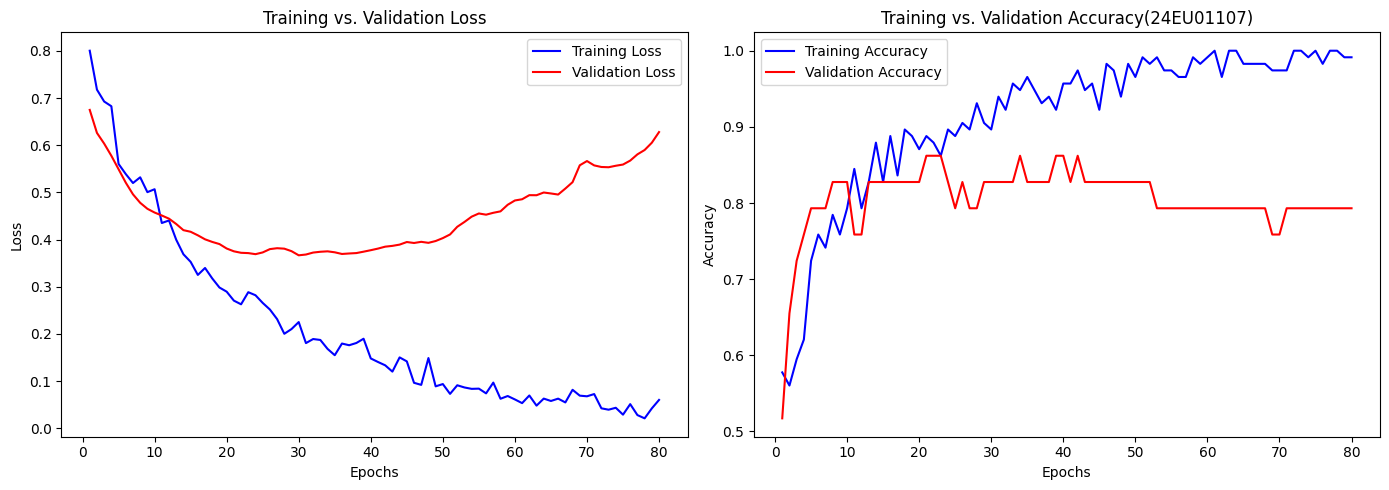

In [68]:
train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("Training vs. Validation Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot accuracy curves
axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("Training vs. Validation Accuracy(24EU01107)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import classification_report, roc_curve, auc

In [71]:
import matplotlib.pyplot as plt

In [72]:
sonar_probs = ann_sonar.predict(X_test_s)[:, 0]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [73]:
sonar_preds = (sonar_probs >= 0.5).astype(int)


--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.79      0.90      0.84        29
    Mine (1)       0.90      0.79      0.84        34

    accuracy                           0.84        63
   macro avg       0.84      0.85      0.84        63
weighted avg       0.85      0.84      0.84        63



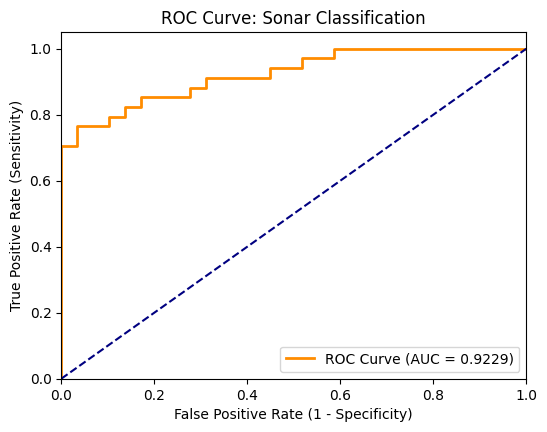

In [74]:
print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

# Compute ROC curve coordinates and AUC score
fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve: Sonar Classification")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()


In [75]:
import tensorflow as tf

In [76]:
from tensorflow.keras.models import Sequential

In [77]:
from tensorflow.keras.layers import Dense

In [78]:
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Modular ANN model builder function established.")

Modular ANN model builder function established.


In [79]:
optimizers = ['adam', 'sgd', 'rmsprop']
history_records = {}

print("--- Running Optimizer Search ---")
for opt in optimizers:
    print(f"Training network using: {opt}...")
    temp_model = build_ann_model(optimizer_name=opt)

    # Fit for 30 epochs
    hist = temp_model.fit(
        X_train_p,
        y_train_p,
        validation_split=0.2,
        epochs=30,
        batch_size=16,
        verbose=0
    )
    history_records[opt] = hist.history['loss']

print("Tuning loop complete.")

--- Running Optimizer Search ---
Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...
Tuning loop complete.


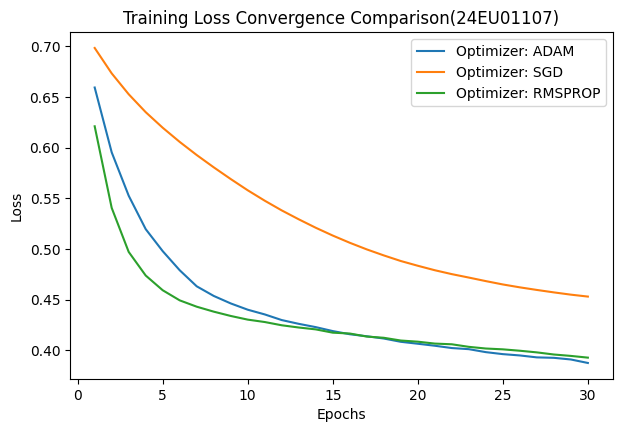

In [80]:
import matplotlib.pyplot as plt

# Plot optimizer training loss profiles
plt.figure(figsize=(7, 4.5))
for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("Training Loss Convergence Comparison(24EU01107)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [81]:
from tensorflow.keras.callbacks import EarlyStopping

# Configure EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Build model with the optimal optimizer found
tuned_model = build_ann_model(optimizer_name='adam')

print("Training model with Early Stopping...")
# Fit model for up to 100 epochs
history_tuned = tuned_model.fit(
    X_train_p,
    y_train_p,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Training model with Early Stopping...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6640 - loss: 0.6403 - val_accuracy: 0.6829 - val_loss: 0.6007
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7291 - loss: 0.5725 - val_accuracy: 0.7317 - val_loss: 0.5411
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7556 - loss: 0.5246 - val_accuracy: 0.7642 - val_loss: 0.4966
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7739 - loss: 0.4892 - val_accuracy: 0.7805 - val_loss: 0.4727
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7800 - loss: 0.4680 - val_accuracy: 0.7724 - val_loss: 0.4573
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7760 - loss: 0.4561 - val_accuracy: 0.7967 - val_loss: 0.4487
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7760 - loss: 0.4486 - val_accuracy: 0.8049 - val_loss: 0.4423
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7841 -

In [82]:
from sklearn.metrics import accuracy_score

# Evaluate baseline model from Task 1
baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]

# Evaluate the tuned, early-stopped model
tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]

comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

print("--- Final Performance Comparison ---")
print(comparison_df.to_string(index=False))

--- Final Performance Comparison ---
            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          75.974023              50
Tuned ANN (with Early Stopping)          70.129871              30
